# Download the datasets from Census

https://www.census.gov/data/datasets/time-series/demo/cps/cps-asec.html 

In [12]:
import glob
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('../data/pppub26.csv')


In [5]:
df.head(5)

,PERIDNUM,PH_SEQ,P_SEQ,A_LINENO,PF_SEQ,PHF_SEQ,OED_TYP1,OED_TYP2,OED_TYP3,PERRP,...,I_DISVL1,I_DISVL2,I_SURVL1,I_SURVL2,MIG_CBST,MIG_DSCP,DEP_STAT,FILEDATE,FILESTAT,YYYYMM
0,0220090932130451801101,1,1,1,1,1,0,0,0,40,...,0,0,0,0,0,0,0,72726,6,202603
1,0220090932130451801102,1,2,2,1,1,0,0,0,42,...,0,0,0,0,0,0,0,72726,6,202603
2,0920610526130572011101,5,1,1,1,1,0,0,0,41,...,0,0,0,0,1,2,0,72726,5,202603
3,5530995720600121801101,6,1,1,1,1,0,0,0,41,...,0,0,0,0,0,0,0,72726,5,202603
4,3216091124049302001101,13,1,1,1,1,0,0,0,41,...,0,0,0,0,0,0,0,72726,6,202603


In [8]:

person_cols = [
    # ① NEET 
    'A_AGE', 'A_ENRLW', 'A_FTPT', 'A_HSCOL', 'A_LFSR', 'MARSUPWT',
    # ② unemployment vs. inactive
    'A_WANTJB', 'A_NLFLJ', 'A_WKSLK', 'RSNNOTW', 'WKSWORK',
    # ③ individual risk
    'A_SEX', 'PRDTRACE', 'PEHSPNON', 'A_HGA', 'PRCITSHP', 'PENATVTY', 'A_MARITL',
    'PRDISFLG', 'PEDISEAR', 'PEDISEYE', 'PEDISREM', 'PEDISPHY', 'PEDISDRS', 'PEDISOUT',
    'PEAFEVER',
    # ④ family 
    'PERRP', 'A_FAMREL', 'PEPAR1', 'PEPAR2',
    # ⑥ support
    'ED_YN', 'OED_TYP1', 'OED_TYP2', 'OED_TYP3', 'COV',
    # concat id
    'PH_SEQ', 'PF_SEQ', 'P_SEQ', 'A_LINENO',
]

pp = pd.read_csv('../data/pppub26.csv', usecols=person_cols)


In [9]:
ff = pd.read_csv('../data/ffpub26.csv',
                 usecols=['FH_SEQ', 'FFPOS', 'FOWNU18', 'FOWNU6', 'FTOTVAL', 'FAMLIS', 'FINC_PAW'])
hh = pd.read_csv('../data/hhpub26.csv',
                 usecols=['H_SEQ', 'H_TENURE', 'GESTFIPS', 'GTMETSTA', 'GTCBSA'])

df = (pp.merge(ff, left_on=['PH_SEQ', 'PF_SEQ'], right_on=['FH_SEQ', 'FFPOS'], how='left')
        .merge(hh, left_on='PH_SEQ', right_on='H_SEQ', how='left'))


In [11]:
df.columns

Index(['PH_SEQ', 'P_SEQ', 'A_LINENO', 'PF_SEQ', 'OED_TYP1', 'OED_TYP2',
       'OED_TYP3', 'PERRP', 'PEHSPNON', 'PEAFEVER', 'PENATVTY', 'PEPAR1',
       'PEPAR2', 'PRDTRACE', 'PRCITSHP', 'PEDISEAR', 'PEDISEYE', 'PEDISREM',
       'PEDISPHY', 'PEDISDRS', 'PEDISOUT', 'PRDISFLG', 'A_AGE', 'A_SEX',
       'A_WANTJB', 'A_ENRLW', 'A_HSCOL', 'A_FTPT', 'A_FAMREL', 'A_WKSLK',
       'A_MARITL', 'A_HGA', 'A_LFSR', 'A_NLFLJ', 'MARSUPWT', 'COV', 'ED_YN',
       'RSNNOTW', 'WKSWORK', 'FOWNU6', 'FOWNU18', 'FH_SEQ', 'FAMLIS', 'FFPOS',
       'FINC_PAW', 'FTOTVAL', 'GESTFIPS', 'H_TENURE', 'H_SEQ', 'GTCBSA',
       'GTMETSTA'],
      dtype='object')

# Define NEET populations (0/1)

In [17]:
# NEET = age 16-24, not enrolled last week (A_ENRLW=2), unemployed or NILF (A_LFSR in 3,4,7)
df['NEET'] = (
    df['A_AGE'].between(16, 24)
    & (df['A_ENRLW'] == 2)
    & df['A_LFSR'].isin([3, 4, 7])
).astype(int)

df['NEET'].value_counts()

NEET
0    133128
1      1601
Name: count, dtype: int64

In [22]:
df["A_WKSLK"]

0         0
1         0
2         0
3         0
4         0
         ..
134724    0
134725    0
134726    0
134727    0
134728    8
Name: A_WKSLK, Length: 134729, dtype: int64

In [ ]:
# UNEMP_LOOK = job-search duration > 0 (A_WKSLK) and unemployed, looking (A_LFSR=3)
df['UNEMP_LOOK'] = ((df['A_WKSLK'] > 0) & (df['A_LFSR'] == 3)).astype(int)

df['UNEMP_LOOK'].value_counts()

# Prediction model for NEET / Unemployment

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.inspection import permutation_importance

# youth 16-24 + derived features
youth = df[df['A_AGE'].between(16, 24)].copy()
youth['LIVES_W_PARENT'] = ((youth['PEPAR1'] > 0) | (youth['PEPAR2'] > 0)).astype(int)
youth['FOREIGN_BORN'] = (youth['PENATVTY'] != 57).astype(int)  # 57 = born in US

cat_cols = ['A_SEX', 'PRDTRACE', 'PEHSPNON', 'PRCITSHP', 'A_MARITL',
            'PRDISFLG', 'PEDISEAR', 'PEDISEYE', 'PEDISREM', 'PEDISPHY', 'PEDISDRS', 'PEDISOUT',
            'PEAFEVER', 'PERRP', 'A_FAMREL', 'H_TENURE', 'GESTFIPS', 'GTMETSTA',
            'ED_YN', 'OED_TYP1', 'OED_TYP2', 'OED_TYP3', 'COV', 'FINC_PAW']
num_cols = ['A_AGE', 'A_HGA', 'FOREIGN_BORN', 'LIVES_W_PARENT',
            'FOWNU18', 'FOWNU6', 'FTOTVAL', 'FAMLIS']
X = youth[cat_cols + num_cols]

pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols),
])
pre_dense = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), cat_cols),
    ('num', 'passthrough', num_cols),
])
models = {
    'Logistic': Pipeline([('pre', pre), ('m', LogisticRegression(max_iter=2000, class_weight='balanced'))]),
    'DecisionTree': Pipeline([('pre', pre_dense), ('m', DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=0))]),
    'RandomForest': Pipeline([('pre', pre_dense), ('m', RandomForestClassifier(n_estimators=500, min_samples_leaf=5, class_weight='balanced', n_jobs=-1, random_state=0))]),
    'GradBoost': Pipeline([('pre', pre_dense), ('m', HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, random_state=0))]),
}

c:\Users\Samsung\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [25]:
# 5-fold stratified CV: ROC-AUC + PR-AUC (PR-AUC matters more for rare outcomes; compare to base_rate)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
rows = []
for target in ['NEET', 'UNEMP_LOOK']:
    y = youth[target]
    for name, model in models.items():
        s = cross_validate(model, X, y, cv=cv, scoring=['roc_auc', 'average_precision'])
        rows.append({'target': target, 'model': name, 'base_rate': y.mean(),
                     'ROC_AUC': s['test_roc_auc'].mean(), 'PR_AUC': s['test_average_precision'].mean()})
results = pd.DataFrame(rows).round(3)
results

,target,model,base_rate,ROC_AUC,PR_AUC
0,NEET,Logistic,0.111,0.761,0.348
1,NEET,DecisionTree,0.111,0.760,0.321
2,NEET,RandomForest,0.111,0.806,0.438
3,NEET,GradBoost,0.111,0.809,0.445
4,UNEMP_LOOK,Logistic,0.042,0.617,0.066
5,UNEMP_LOOK,DecisionTree,0.042,0.582,0.055
6,UNEMP_LOOK,RandomForest,0.042,0.646,0.082
7,UNEMP_LOOK,GradBoost,0.042,0.639,0.077


In [26]:
# permutation importance of the best model (GradBoost) on a 25% hold-out
imp = {}
for target in ['NEET', 'UNEMP_LOOK']:
    y = youth[target]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)
    m = models['GradBoost'].fit(Xtr, ytr)
    pi = permutation_importance(m, Xte, yte, scoring='roc_auc', n_repeats=5, random_state=0, n_jobs=-1)
    imp[target] = pd.Series(pi.importances_mean, index=X.columns)
pd.DataFrame(imp).sort_values('NEET', ascending=False).head(10).round(4)

,NEET,UNEMP_LOOK
A_AGE,0.0853,0.0136
A_HGA,0.0844,0.0573
FTOTVAL,0.0389,0.0319
A_FAMREL,0.0250,0.0189
PRDISFLG,0.0083,-0.0004
FAMLIS,0.0067,0.0069
A_SEX,0.0065,0.0047
GESTFIPS,0.0053,-0.0035
A_MARITL,0.0040,0.0030
OED_TYP1,0.0038,0.0015


A total of 32 variables were used for prediction: 24 categorical and 8 numeric. Both models (NEET, UNEMP_LOOK) used the same set of variables.

1) Individual Risk Factors (16 variables)

Variable	Description	Type
A_AGE	Age (added as a control variable)	Numeric
A_SEX	Sex	Categorical
PRDTRACE	Race	Categorical
PEHSPNON	Hispanic origin	Categorical
A_HGA	Educational attainment	Numeric (ordinal education level)
PRCITSHP	Citizenship status	Categorical
FOREIGN_BORN	Foreign-born (derived from PENATVTY)	Numeric (0/1)
A_MARITL	Marital status	Categorical
PRDISFLG	Disability status	Categorical
PEDISEAR	Hearing disability	Categorical
PEDISEYE	Vision disability	Categorical
PEDISREM	Cognitive disability	Categorical
PEDISPHY	Physical (ambulatory) disability	Categorical
PEDISDRS	Self-care disability	Categorical
PEDISOUT	Independent living difficulty	Categorical
PEAFEVER	Military service history	Categorical

2) Family/Household Environment (8 variables)

Variable	Description	Type
PERRP	Relationship to householder	Categorical
A_FAMREL	Family relationship	Categorical
LIVES_W_PARENT	Co-residence with parent(s) (derived from PEPAR1/PEPAR2)	Numeric (0/1)
FOWNU18	Number of own children under 18	Numeric
FOWNU6	Number of own children under 6	Numeric
FTOTVAL	Total family income	Numeric
FAMLIS	Income-to-poverty ratio	Numeric
H_TENURE	Housing tenure (own/rent)	Categorical

3) Geographic (2 variables)

Variable	Description	Type
GESTFIPS	State	Categorical
GTMETSTA	Metropolitan status	Categorical

4) Support/Safety Net (6 variables)

Variable	Description	Type
ED_YN	Receipt of educational assistance	Categorical
OED_TYP1	Educational assistance source 1	Categorical
OED_TYP2	Educational assistance source 2	Categorical
OED_TYP3	Educational assistance source 3	Categorical
COV	Health insurance coverage	Categorical
FINC_PAW	Family receipt of public assistance	Categorical

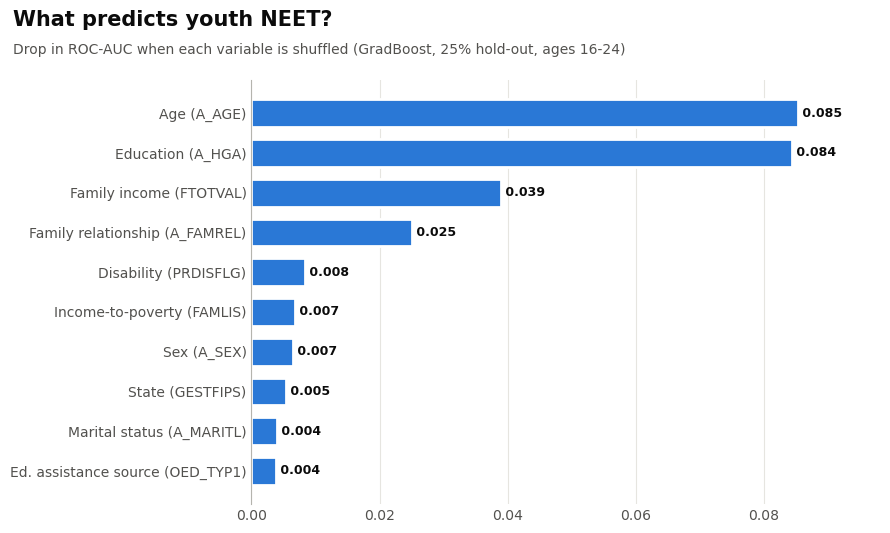

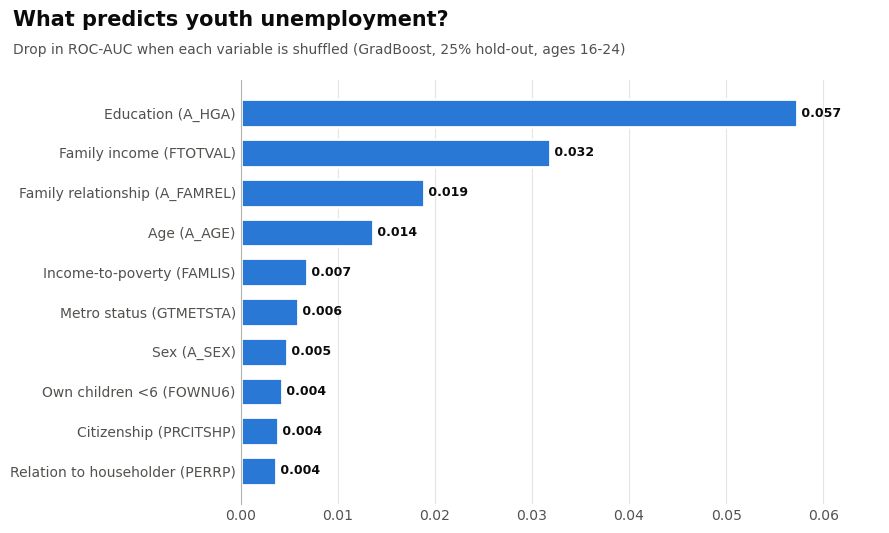

In [29]:
import matplotlib.pyplot as plt

labels = {
    'A_AGE': 'Age', 'A_HGA': 'Education', 'FTOTVAL': 'Family income',
    'A_FAMREL': 'Family relationship', 'PRDISFLG': 'Disability', 'FAMLIS': 'Income-to-poverty',
    'A_SEX': 'Sex', 'GESTFIPS': 'State', 'A_MARITL': 'Marital status', 'OED_TYP1': 'Ed. assistance source',
    'GTMETSTA': 'Metro status', 'FOWNU6': 'Own children <6', 'PRCITSHP': 'Citizenship',
    'PERRP': 'Relation to householder', 'PRDTRACE': 'Race', 'PEHSPNON': 'Hispanic',
    'H_TENURE': 'Home tenure', 'COV': 'Health coverage', 'FOWNU18': 'Own children <18',
    'LIVES_W_PARENT': 'Lives w/ parent', 'FOREIGN_BORN': 'Foreign-born', 'ED_YN': 'Ed. assistance',
}
titles = {
    'NEET': 'What predicts youth NEET?',
    'UNEMP_LOOK': 'What predicts youth unemployment?',
}

for target in ['NEET', 'UNEMP_LOOK']:
    s = imp[target].sort_values().tail(10)

    fig, ax = plt.subplots(figsize=(9, 5.5))
    bars = ax.barh([f'{labels.get(c, c)} ({c})' for c in s.index], s.values,
                   height=0.7, color='#2a78d6', edgecolor='white', linewidth=2)
    ax.bar_label(bars, fmt=' %.3f', fontsize=9, fontweight='bold', color='#0b0b0b')

    fig.text(0.02, 0.96, titles[target], fontsize=15, fontweight='bold', color='#0b0b0b', va='top')
    fig.text(0.02, 0.90, 'Drop in ROC-AUC when each variable is shuffled (GradBoost, 25% hold-out, ages 16-24)',
             fontsize=10, color='#52514e', va='top')
    ax.set_xlim(0, s.max() * 1.15)
    ax.xaxis.grid(True, color='#e6e5e0', lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0, colors='#52514e')
    for side in ['top', 'right', 'bottom']:
        ax.spines[side].set_visible(False)
    ax.spines['left'].set_color('#b5b4ae')
    plt.tight_layout(rect=[0, 0, 1, 0.86])
    plt.savefig(f'fig_importance_{target.lower()}.png', dpi=200)
    plt.show()

In [31]:
# Interactive NEET explorer: pick a variable -> actual NEET rate (bars) vs model-predicted rate (dots) by group
import plotly.graph_objects as go
from sklearn.model_selection import cross_val_predict

# out-of-fold predicted NEET probability, so each person is scored by a model that never saw them
youth['NEET_PRED'] = cross_val_predict(models['GradBoost'], X, youth['NEET'], cv=cv, method='predict_proba')[:, 1]

yes_no = {1: 'Yes', 2: 'No', -1: 'N/A'}
states = {1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT', 10: 'DE', 11: 'DC', 12: 'FL', 13: 'GA',
          15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN', 19: 'IA', 20: 'KS', 21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD',
          25: 'MA', 26: 'MI', 27: 'MN', 28: 'MS', 29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV', 33: 'NH', 34: 'NJ',
          35: 'NM', 36: 'NY', 37: 'NC', 38: 'ND', 39: 'OH', 40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC',
          46: 'SD', 47: 'TN', 48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV', 55: 'WI', 56: 'WY'}
value_labels = {
    'A_SEX': {1: 'Male', 2: 'Female'},
    'PEHSPNON': {1: 'Hispanic', 2: 'Not Hispanic'},
    'PRDTRACE': {1: 'White', 2: 'Black', 3: 'AIAN', 4: 'Asian', 5: 'NHPI', **{k: 'Two or more' for k in range(6, 27)}},
    'A_HGA': {**{k: '8th grade or less' for k in range(31, 35)}, 35: '9th grade', 36: '10th grade', 37: '11th grade',
              38: '12th, no diploma', 39: 'HS graduate', 40: 'Some college', 41: 'Assoc. (vocational)',
              42: 'Assoc. (academic)', 43: "Bachelor's", 44: "Master's", 45: 'Professional', 46: 'Doctorate'},
    'PRCITSHP': {1: 'US-born', 2: 'Born in PR/territory', 3: 'Born abroad, US parent', 4: 'Naturalized', 5: 'Not a citizen'},
    'A_MARITL': {1: 'Married', 2: 'Married', 3: 'Married, spouse absent', 4: 'Widowed', 5: 'Divorced', 6: 'Separated', 7: 'Never married'},
    'A_FAMREL': {0: 'Not in a family', 1: 'Reference person', 2: 'Spouse', 3: 'Child', 4: 'Other relative'},
    'H_TENURE': {1: 'Owned', 2: 'Rented', 3: 'No cash rent'},
    'GTMETSTA': {1: 'Metro', 2: 'Non-metro', 3: 'Not identified'},
    'FAMLIS': {1: 'Below poverty', 2: '100-124% of poverty', 3: '125-149% of poverty', 4: '150%+ of poverty'},
    'FOREIGN_BORN': {0: 'US-born', 1: 'Foreign-born'},
    'LIVES_W_PARENT': {0: 'No', 1: 'Yes'},
    'GESTFIPS': states,
    **{c: yes_no for c in ['PRDISFLG', 'PEDISEAR', 'PEDISEYE', 'PEDISREM', 'PEDISPHY', 'PEDISDRS', 'PEDISOUT',
                           'PEAFEVER', 'ED_YN', 'COV', 'FINC_PAW']},
}

def groups(col):
    v = youth[col]
    if col == 'FTOTVAL':
        return pd.qcut(v, 5, labels=['Bottom 20%', '20-40%', '40-60%', '60-80%', 'Top 20%'])
    if col in ['FOWNU18', 'FOWNU6']:
        return v.clip(upper=2).map({0: '0', 1: '1', 2: '2+'})
    if col == 'A_AGE':
        return v.astype(str)
    return v.map(value_labels[col]).fillna('Code ' + v.astype(str)) if col in value_labels else 'Code ' + v.astype(str)

ordered = ['A_AGE', 'A_HGA', 'FTOTVAL', 'FAMLIS', 'FOWNU18', 'FOWNU6']  # keep natural order; others sort by rate

def rate_table(col, min_n=30):
    t = (youth.assign(grp=groups(col), w=youth['MARSUPWT'])
              .groupby('grp', observed=True)
              .apply(lambda d: pd.Series({
                  'actual': (d['NEET'] * d['w']).sum() / d['w'].sum() * 100,
                  'pred': (d['NEET_PRED'] * d['w']).sum() / d['w'].sum() * 100,
                  'n': len(d),
                  'key': d[col].mean()})))
    t = t[t['n'] >= min_n]  # drop tiny groups: rates are too noisy
    return t.sort_values('key') if col in ordered else t.sort_values('actual', ascending=False)

overall = (youth['NEET'] * youth['MARSUPWT']).sum() / youth['MARSUPWT'].sum() * 100
var_order = imp['NEET'].sort_values(ascending=False).index.tolist()  # dropdown sorted by importance

fig = go.Figure()
for i, col in enumerate(var_order):
    t = rate_table(col)
    x = t.index.astype(str)
    fig.add_bar(x=x, y=t['actual'], name='Actual NEET rate', marker_color='#2a78d6', visible=(i == 0),
                customdata=t['n'], legendgroup='a', showlegend=True,
                hovertemplate='<b>%{x}</b><br>Actual NEET rate: %{y:.1f}%<br>n = %{customdata:,.0f}<extra></extra>')
    fig.add_scatter(x=x, y=t['pred'], name='Model-predicted rate', mode='markers', visible=(i == 0),
                    marker=dict(color='#eb6834', size=11, line=dict(color='white', width=2)), legendgroup='p',
                    hovertemplate='<b>%{x}</b><br>Predicted NEET rate: %{y:.1f}%<extra></extra>')

descriptions = {
    'A_AGE': 'Age in years at the time of the survey.',
    'A_SEX': 'Sex of the respondent.',
    'PRDTRACE': 'Detailed race; all multiracial combinations are grouped as "Two or more".',
    'PEHSPNON': 'Whether the person is of Hispanic, Latino, or Spanish origin.',
    'A_HGA': 'Highest grade completed or degree received.',
    'PRCITSHP': 'Citizenship status, from US-born to non-citizen.',
    'FOREIGN_BORN': 'Derived from PENATVTY: born outside the United States.',
    'A_MARITL': 'Current marital status.',
    'PRDISFLG': 'Has any of the six disabilities (hearing, vision, cognitive, walking, self-care, independent living).',
    'PEDISEAR': 'Deaf or serious difficulty hearing.',
    'PEDISEYE': 'Blind or serious difficulty seeing, even with glasses.',
    'PEDISREM': 'Serious difficulty concentrating, remembering, or making decisions.',
    'PEDISPHY': 'Serious difficulty walking or climbing stairs.',
    'PEDISDRS': 'Difficulty dressing or bathing.',
    'PEDISOUT': 'Difficulty doing errands alone, such as visiting a doctor or shopping.',
    'PEAFEVER': 'Has ever served on active duty in the US Armed Forces.',
    'PERRP': "Detailed relationship to the household's reference person (Census codes).",
    'A_FAMREL': 'Role within the family: reference person, spouse, child, or other relative.',
    'LIVES_W_PARENT': 'Derived from PEPAR1/PEPAR2: at least one parent lives in the same household.',
    'FOWNU18': 'Number of own children under 18 in the family. Identifies young parents.',
    'FOWNU6': 'Number of own children under 6 in the family. Identifies parents of young kids.',
    'FTOTVAL': 'Total family income last year, split into quintiles among youth.',
    'FAMLIS': "Family income relative to the federal poverty line.",
    'H_TENURE': 'Whether the household owns or rents its home.',
    'GESTFIPS': 'State of residence (only states with 30+ sampled youth shown).',
    'GTMETSTA': 'Whether the household is in a metropolitan area.',
    'ED_YN': 'Received any educational assistance (grants, scholarships, loans) last year.',
    'OED_TYP1': 'First source of educational assistance (Census codes).',
    'OED_TYP2': 'Second source of educational assistance (Census codes).',
    'OED_TYP3': 'Third source of educational assistance (Census codes).',
    'COV': 'Had any health insurance coverage last year.',
    'FINC_PAW': 'Family received public assistance or welfare last year.',
}

def title(col):
    return (f"<b>Youth NEET rate by {labels.get(col, col)} ({col})</b>"
            f"<br><span style='font-size:13px;color:#0b0b0b'>{descriptions.get(col, '')}</span>"
            f"<br><span style='font-size:12px;color:#52514e'>Ages 16-24, weighted. Importance rank "
            f"{var_order.index(col) + 1} of {len(var_order)}. Dashed line = overall {overall:.1f}%</span>")

buttons = [dict(label=f'{labels.get(c, c)} ({c})', method='update',
                args=[{'visible': [j // 2 == i for j in range(2 * len(var_order))]}, {'title.text': title(c)}])
           for i, c in enumerate(var_order)]

fig.add_hline(y=overall, line=dict(color='#8a8984', dash='dash', width=1.5))
fig.update_layout(
    title=dict(text=title(var_order[0]), x=0.01, xanchor='left', y=0.975, font=dict(size=17, color='#0b0b0b')),
    updatemenus=[dict(buttons=buttons, direction='down', x=0.01, xanchor='left', y=1.2, yanchor='top',
                      bgcolor='white', bordercolor='#b5b4ae', font=dict(size=12))],
    annotations=[dict(text='Variable:', x=0, xref='paper', xanchor='right', y=1.18, yref='paper', showarrow=False,
                      font=dict(size=12, color='#52514e'))],
    legend=dict(orientation='h', x=0, y=-0.18, font=dict(size=12)),
    margin=dict(t=175, l=90, r=30, b=110), height=590, width=950,
    plot_bgcolor='white', paper_bgcolor='white', bargap=0.3,
    yaxis=dict(title='% NEET', ticksuffix='%', gridcolor='#e6e5e0', zeroline=False, color='#52514e', rangemode='tozero'),
    xaxis=dict(color='#52514e', linecolor='#b5b4ae', tickangle=-30),
    hoverlabel=dict(bgcolor='white', font_size=12),
)
fig.show()

C:\Users\Samsung\AppData\Local\Temp\ipykernel_56788\1058515605.py:47: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\Samsung\AppData\Local\Temp\ipykernel_56788\1058515605.py:47: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\Samsung\AppData\Local\Temp\ipykernel_56788\1058515605.py:47: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future 

* Education: The groups with the highest NEET rates are high school graduates (22.8%) and those with middle school education or below (20.7%). Youth who finished high school but did not go on to college form the core at-risk group.
* Family income: The bottom 20% shows a NEET rate of 18.9%, versus 4.8% for the top 20%—roughly a fourfold difference.